<a href="https://colab.research.google.com/github/ferdinano/Aprendizaje_automatico_2026/blob/main/clase%205/Ejercico_clase_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación entre K-Nearest Neighbors (KNN) y Árboles de Decisión

Usaremos un dataset diabetes de 768 pacientes con síntomas para predecir si tienen:
- 0 = no tiene diabetes
- 1 = tiene diabetes


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns

## Leemos los datos

In [14]:
# cargar datos de un csv
df = pd.read_csv("/content/diabetes_data.csv")
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [15]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


División en entrenamiento y prueba

In [16]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Seleccionamos dos variables para la visualizacion K _ NN

In [25]:
# Visualización en 2D del modelo KNN usando 'Age' y 'BMI'

# Seleccionamos solo dos variables
X_simple2 = df[["Age", "BMI"]]
y_simple2 = df["Outcome"]

# División en entrenamiento y prueba
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_simple2, y_simple2, test_size=0.3, random_state=42
)

# Escalamos los datos
scaler = StandardScaler()
X_train_s2_scaled = scaler.fit_transform(X_train_s2)
X_test_s2_scaled = scaler.transform(X_test_s2)

# Entrenamos el modelo KNN
knn_simple2 = KNeighborsClassifier(n_neighbors=14, weights='distance')
knn_simple2.fit(X_train_s2_scaled, y_train_s2)

KNeighborsClassifier(n_neighbors=14, weights='distance')

/tmp/ipykernel_11234/479663516.py:8: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


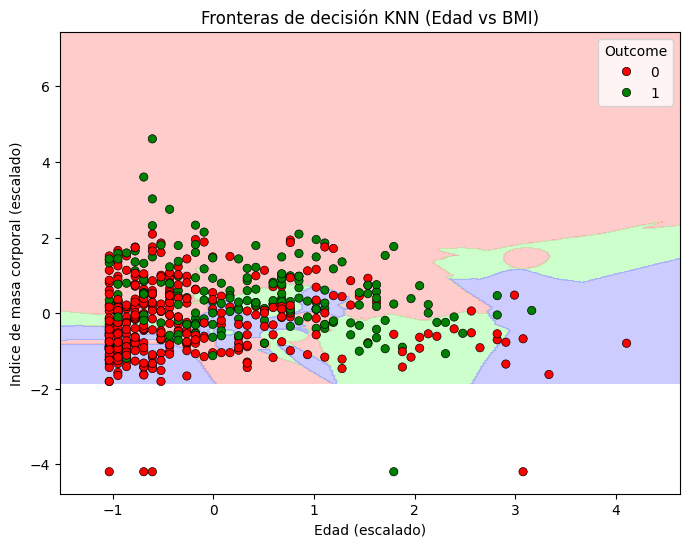

In [27]:
# Colores
cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA", "#AAAAFF"])
cmap_bold = ["red", "green", "blue"]

# Gráfico
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
sns.scatterplot(
    x=X_train_s2_scaled[:, 0],
    y=X_train_s2_scaled[:, 1],
    hue=y_train_s2,
    palette=cmap_bold,
    edgecolor="k"
)
plt.title("Fronteras de decisión KNN (Edad vs BMI)")
plt.xlabel("Edad (escalado)")
plt.ylabel("Indice de masa corporal (escalado)")
plt.show()

# evaluacion del modelo K-NN utilizando metricas y matriz de confusiòn

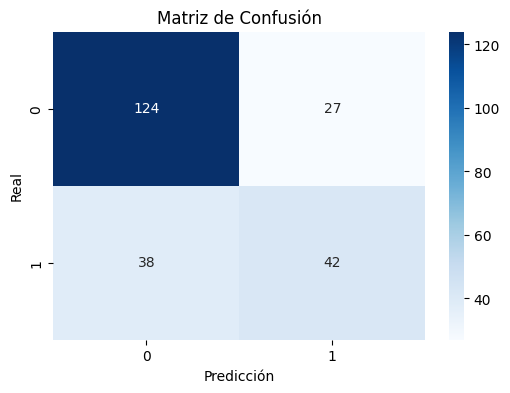

In [28]:
# Usamos la matriz de confusion
knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(knn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [24]:
knn = KNeighborsClassifier(n_neighbors=14, weights='distance')

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("Métricas KNN:")
print(classification_report(y_test, y_pred_knn))




Métricas KNN:
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       151
           1       0.61      0.53      0.56        80

    accuracy                           0.72       231
   macro avg       0.69      0.67      0.68       231
weighted avg       0.71      0.72      0.71       231



## Árbol de Decisión



In [29]:
tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

           0       0.85      0.68      0.75       151
           1       0.56      0.78      0.65        80

    accuracy                           0.71       231
   macro avg       0.70      0.73      0.70       231
weighted avg       0.75      0.71      0.72       231



Visualización del Árbol de Decisión

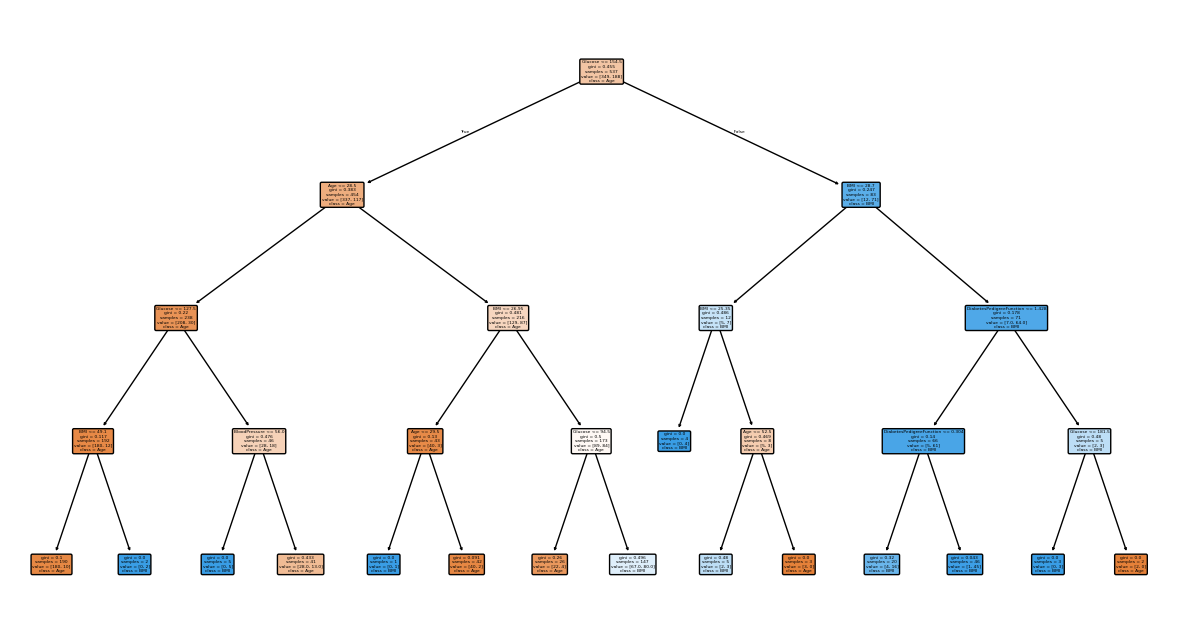

In [30]:
plt.figure(figsize=(15,8))
plot_tree(tree, feature_names=X.columns, class_names=["Age", "BMI"], filled=True, rounded=True)
plt.show()

Accuracy KNN: 0.7186147186147186
Accuracy Árbol: 0.70995670995671


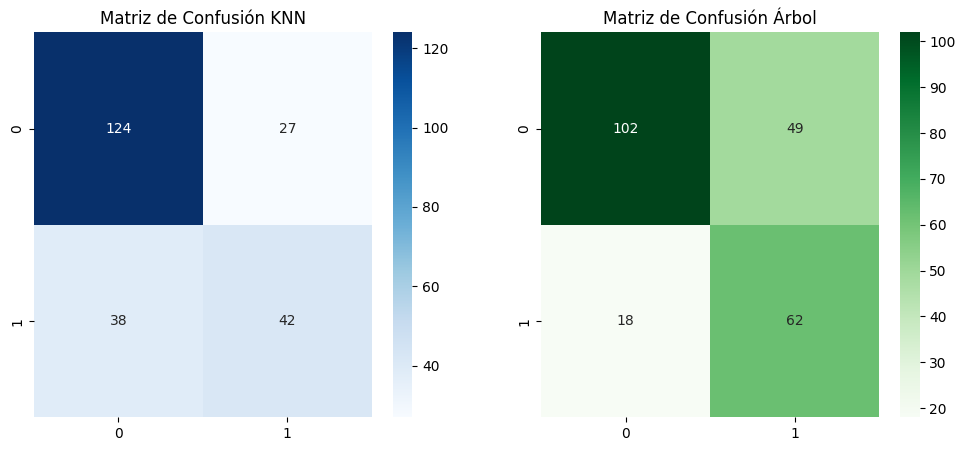

In [31]:
print("Accuracy KNN:", accuracy_score(y_test, y_pred_knn))
print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Matriz de Confusión KNN")

sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("Matriz de Confusión Árbol")
plt.show()

# Análisis
En este trabajo de aplicaron dos modelos de aprendizaje automático supervisado, K-NN y árbol de Decisión, donde se debe identificar si tiene o no diabetes. Base de datos obtenida en kaggle.
El modelo de K-NN se destaca por ser bueno en identificar la clase 0 (no tiene diabetes), pero tiene dificultades con identificación de la clase 1 (tiene diabetes).
El modelo predijo correctamente 0, 124 casos, equivocándose 27 veces al decir que era 1 cuando en realidad era 0.
En el caso contrario identifico correctamente 1, 42 veces y se equivoco 38 veces, siendo este su punto débil.
En el modelo de árbol de decisiones fue al contrario, es más agresivo prediciendo el caso 1 que el 0, cometiendo mas errores en este.
Pero hay un punto importante en la exactitud del accuracy, casi idéntica del 71%.
